In [ ]:
# =========================================================
# NOTEBOOK: 07_clv_prediction.ipynb
# =========================================================

# =========================================================
# STEP 1 — IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from lightgbm import LGBMRegressor

from catboost import CatBoostRegressor

from sklearn.preprocessing import StandardScaler

import shap

import joblib

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")


Libraries Imported Successfully


In [ ]:
# =========================================================
# STEP 2 — LOAD DATASET
# =========================================================

master_df = pd.read_csv(
r'C:\Users\niran\Desktop\AI_Ecommerce_Customer_Intelligence_Platform\data\processed\statistical_analysis_dataset.csv'
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
# =========================================================
# STEP 3 — DATASET OVERVIEW
# =========================================================

print("\nDataset Shape:")
print(master_df.shape)

print("\nDataset Sample:\n")

print(master_df.head())


Dataset Shape:
(2530433, 87)

Dataset Sample:

                               order_id                           customer_id  \
0  720fd9e9-cdeb-4dec-a187-f71586eb085a  1e2e2881-a0eb-4cb0-829f-a566e810d05f   
1  720fd9e9-cdeb-4dec-a187-f71586eb085a  1e2e2881-a0eb-4cb0-829f-a566e810d05f   
2  720fd9e9-cdeb-4dec-a187-f71586eb085a  1e2e2881-a0eb-4cb0-829f-a566e810d05f   
3  c0142972-63fa-4af2-8070-f583ab769847  380b7418-308c-4bf7-b2bd-3ee446cb9ea6   
4  c0142972-63fa-4af2-8070-f583ab769847  380b7418-308c-4bf7-b2bd-3ee446cb9ea6   

  order_status order_purchase_timestamp    order_approved_at  \
0     canceled      2025-12-27 07:07:20  2025-12-27 08:33:20   
1     canceled      2025-12-27 07:07:20  2025-12-27 08:33:20   
2     canceled      2025-12-27 07:07:20  2025-12-27 08:33:20   
3    delivered      2019-06-07 19:30:44  2019-06-08 05:08:44   
4    delivered      2019-06-07 19:30:44  2019-06-08 05:08:44   

  order_delivered_carrier_date order_delivered_customer_date  \
0               

In [ ]:
# =========================================================
# STEP 4 — CUSTOMER LEVEL DATASET
# =========================================================

customer_df = (master_df.sort_values('order_purchase_timestamp')
               .groupby('customer_unique_id')
               .last()
               .reset_index())

print("\nCustomer-Level Dataset Shape:")
print(customer_df.shape)


Customer-Level Dataset Shape:
(279199, 87)


In [ ]:
# =========================================================
# STEP 5 — CREATE CLV TARGET
# =========================================================

customer_clv = (master_df.groupby('customer_unique_id')['payment_value']
                .sum()
                .reset_index()
                )

customer_clv.columns = ['customer_unique_id', 'CLV']

customer_df = customer_df.merge( customer_clv, on='customer_unique_id', how='left' )

print("\nCLV Target Created")


CLV Target Created



CLV Statistics:

count    2.791990e+05
mean     2.084809e-16
std      7.120831e+00
min     -3.317910e+01
25%     -3.426982e+00
50%     -1.125539e+00
75%      1.637694e+00
max      1.152065e+02
Name: CLV, dtype: float64


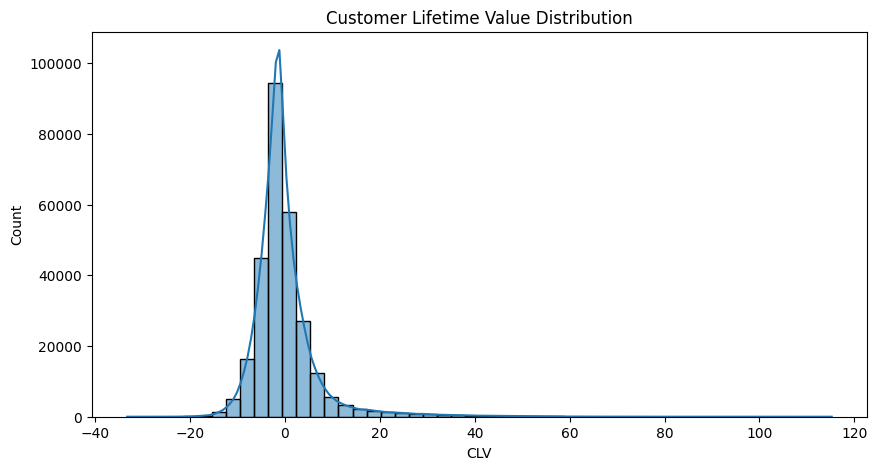

In [ ]:
# =========================================================
# STEP 6 — TARGET DISTRIBUTION
# =========================================================

print("\nCLV Statistics:\n")

print(customer_df['CLV'].describe())

plt.figure(figsize=(10,5))

sns.histplot( customer_df['CLV'], bins=50, kde=True )

plt.title("Customer Lifetime Value Distribution")

plt.show()

In [ ]:
# =========================================================
# STEP 7 — REMOVE LEAKAGE FEATURES
# =========================================================

leakage_cols = [
# TARGET RELATED
'CLV',

# IDS
'customer_id',
'customer_unique_id',
'order_id',
'product_id',
'seller_id',
'review_id',

# DATES
'order_purchase_timestamp',
'order_approved_at',
'order_delivered_carrier_date',
'order_delivered_customer_date',
'order_estimated_delivery_date',
'review_creation_date',
'review_answer_timestamp',

#clv_leakage_cols

'CLV',
'Monetary',
'total_spent',
'avg_order_value',
'payment_value',
'product_revenue',
'seller_total_revenue',
'cost',
'price_x',
'price_y',
'order_item_id',
'customer_segment'


]

# Remove duplicate columns

duplicate_cols = [col for col in customer_df.columns
                  if col.endswith('1') ]

X = customer_df.drop( columns=leakage_cols + duplicate_cols,
                      errors='ignore'
)

y = customer_df['CLV']

print("\nFeature Matrix Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)


Feature Matrix Shape:
(279199, 56)

Target Shape:
(279199,)


In [ ]:
# =========================================================
# STEP 8 — HANDLE CATEGORICAL FEATURES
# =========================================================

cat_cols = X.select_dtypes(include='object').columns

safe_cat_cols = [col for col in cat_cols
                 if X[col].nunique() <= 20 ]

print("\nSafe Categorical Columns:")
print(safe_cat_cols)

X = pd.get_dummies( X, columns=safe_cat_cols, drop_first=True )

# Remove remaining object columns

X = X.select_dtypes(exclude='object')

# Clean column names

X.columns = ( X.columns.str.replace(' ', '_').str.replace('[^A-Za-z0-9_]', '', regex=True) )

print("\nEncoded Feature Shape:")
print(X.shape)


Safe Categorical Columns:
['order_status', 'customer_city', 'customer_state', 'seller_contact_gender', 'seller_city', 'seller_state']

Encoded Feature Shape:
(279199, 86)


In [ ]:
corr_check = X.corrwith(y).sort_values(
    ascending=False
)

print(corr_check.head(10))

unique_products_purchased    0.361684
product_total_orders         0.115678
purchase_month               0.077464
payment_installments         0.053936
payment_credit_card          0.052649
payment_apple_pay            0.048017
freight_value                0.026582
customer_state_CA            0.019107
customer_city_Los_Angeles    0.019107
payment_paypal               0.017075
dtype: float64


In [ ]:
# =========================================================
# STEP 9 — TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 )

print("\nTrain Test Split Completed")

print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape  : {X_test.shape}")



Train Test Split Completed
X_train Shape : (223359, 86)
X_test Shape  : (55840, 86)


In [ ]:
# =========================================================
# STEP 10 — FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling Completed")



Feature Scaling Completed


In [ ]:
# =========================================================
# STEP 11 — LINEAR REGRESSION
# =========================================================

lr_model = LinearRegression()

lr_model.fit( X_train_scaled, y_train )

lr_preds = lr_model.predict(X_test_scaled)

print("\nLinear Regression Trained")



Linear Regression Trained


In [ ]:
# =========================================================
# STEP 12 — DECISION TREE
# =========================================================

dt_model = DecisionTreeRegressor( max_depth=10, random_state=42 )

dt_model.fit( X_train, y_train )

dt_preds = dt_model.predict(X_test)

print("Decision Tree Trained")


Decision Tree Trained


In [ ]:
# =========================================================
# STEP 13 — RANDOM FOREST
# =========================================================

rf_model = RandomForestRegressor( n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Trained")

Random Forest Trained


In [ ]:
# =========================================================
# STEP 14 — XGBOOST
# =========================================================

xgb_model = XGBRegressor( n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42, n_jobs=-1)

xgb_model.fit( X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost Trained")

XGBoost Trained


In [ ]:
# =========================================================
# STEP 15 — LIGHTGBM
# =========================================================

lgbm_model = LGBMRegressor( n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42, n_jobs=-1)

lgbm_model.fit( X_train, y_train )

lgbm_preds = lgbm_model.predict(X_test)

print("LightGBM Trained")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059351 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4737
[LightGBM] [Info] Number of data points in the train set: 223359, number of used features: 85
[LightGBM] [Info] Start training from score -0.000505
LightGBM Trained


In [ ]:
# =========================================================
# STEP 16 — CATBOOST
# =========================================================

cat_model = CatBoostRegressor( iterations=200, learning_rate=0.1, depth=8, random_state=42, verbose=0 )

cat_model.fit( X_train, y_train )

cat_preds = cat_model.predict(X_test)

print("CatBoost Trained")


CatBoost Trained


In [ ]:
# =========================================================
# STEP 17 — EVALUATION FUNCTION
# =========================================================

def evaluate_regression_model(y_true, y_pred, model_name):
    mae = mean_absolute_error( y_true, y_pred)

    rmse = np.sqrt( mean_squared_error( y_true, y_pred ))

    r2 = r2_score(y_true, y_pred)

    print("\n===================================================")
    print(f"{model_name} PERFORMANCE")
    print("===================================================")

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}")

In [ ]:
# =========================================================
# STEP 18 — MODEL EVALUATION
# =========================================================

evaluate_regression_model( y_test, lr_preds, "Linear Regression" )

evaluate_regression_model( y_test, dt_preds, "Decision Tree")

evaluate_regression_model( y_test, rf_preds, "Random Forest")

evaluate_regression_model( y_test, xgb_preds,"XGBoost" )

evaluate_regression_model( y_test, lgbm_preds, "LightGBM")

evaluate_regression_model( y_test, cat_preds, "CatBoost")


Linear Regression PERFORMANCE
MAE  : 3.46
RMSE : 5.01
R2   : 0.4978

Decision Tree PERFORMANCE
MAE  : 3.26
RMSE : 5.01
R2   : 0.4985

Random Forest PERFORMANCE
MAE  : 3.09
RMSE : 4.70
R2   : 0.5586

XGBoost PERFORMANCE
MAE  : 3.05
RMSE : 4.66
R2   : 0.5667

LightGBM PERFORMANCE
MAE  : 3.05
RMSE : 4.63
R2   : 0.5707

CatBoost PERFORMANCE
MAE  : 3.05
RMSE : 4.62
R2   : 0.5726


In [ ]:
# =========================================================
# STEP 19 — CROSS VALIDATION
# =========================================================

print("\n================ CROSS VALIDATION ================\n")

cv_scores = cross_val_score( lgbm_model, X, y, cv=5, scoring='r2', n_jobs=-1)

print("LightGBM CV Scores:")
print(cv_scores)

print(f"\nAverage CV Score: {cv_scores.mean():.4f}")


================ CROSS VALIDATION ================

LightGBM CV Scores:
[0.57041117 0.57601567 0.57107216 0.56928723 0.57006085]

Average CV Score: 0.5714


In [ ]:
# =========================================================
# STEP 20 — HYPERPARAMETER TUNING
# =========================================================

print("\n================ LIGHTGBM TUNING ================\n")

param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [5, 8]}

grid_search = GridSearchCV( estimator=LGBMRegressor( random_state=42,
                                                     n_jobs=-1),
                                                     param_grid=param_grid,
                                                     scoring='r2',
                                                     cv=3,
                                                     n_jobs=-1,
                                                     verbose=1)

grid_search.fit( X_train, y_train )

best_lgbm_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)


================ LIGHTGBM TUNING ================

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048495 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4737
[LightGBM] [Info] Number of data points in the train set: 223359, number of used features: 85
[LightGBM] [Info] Start training from score -0.000505
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

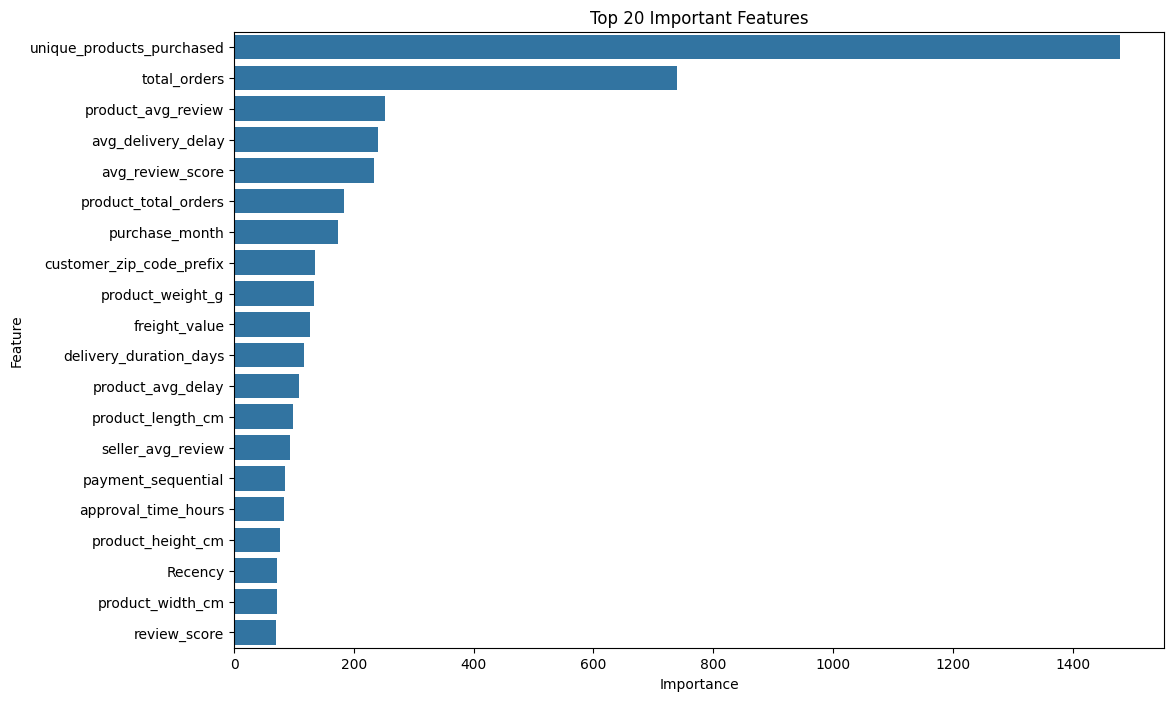

In [ ]:
# =========================================================
# STEP 21 — FEATURE IMPORTANCE
# =========================================================

feature_importance = pd.DataFrame({'Feature': X.columns,
                                   'Importance': best_lgbm_model.feature_importances_})

feature_importance = (feature_importance.sort_values( by='Importance', ascending=False ).head(20) )

plt.figure(figsize=(12,8))

sns.barplot( x='Importance', y='Feature', data=feature_importance )

plt.title("Top 20 Important Features")

plt.show()


================ SHAP ANALYSIS ================



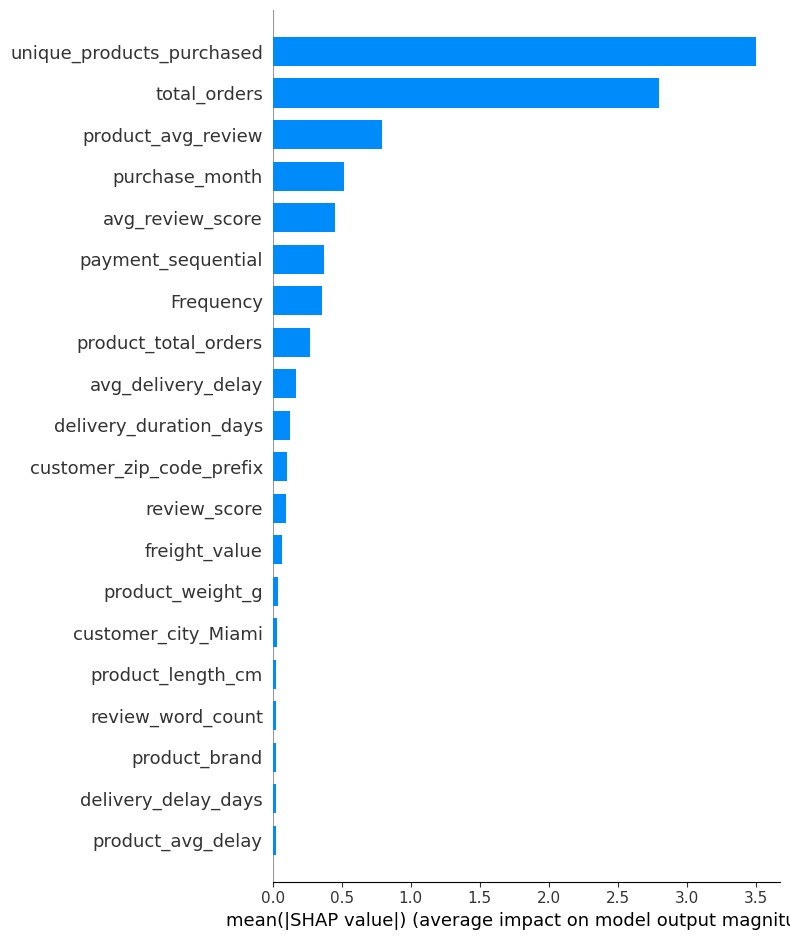

In [ ]:
# =========================================================
# STEP 22 — SHAP EXPLAINABILITY
# =========================================================

print("\n================ SHAP ANALYSIS ================\n")

sample_X = X_test.sample( 2000, random_state=42 )

explainer = shap.TreeExplainer( best_lgbm_model )

shap_values = explainer.shap_values( sample_X )

shap.summary_plot( shap_values, sample_X, plot_type='bar')


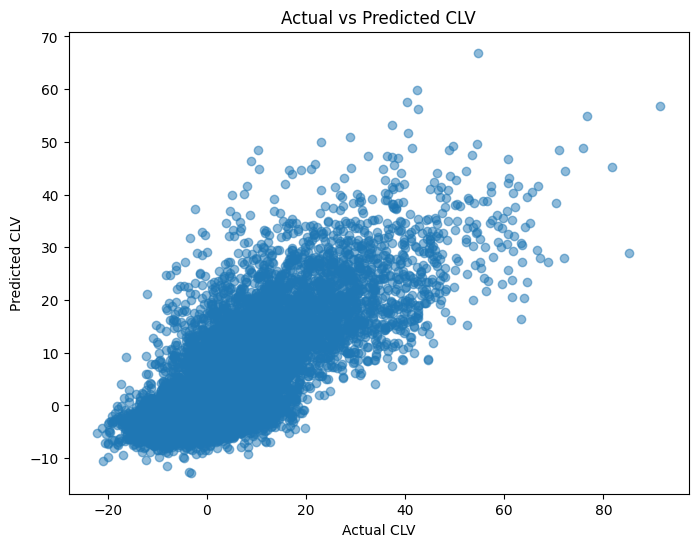

In [ ]:
# =========================================================
# STEP 23 — ACTUAL VS PREDICTED
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter( y_test, lgbm_preds, alpha=0.5)

plt.xlabel("Actual CLV")

plt.ylabel("Predicted CLV")

plt.title("Actual vs Predicted CLV")

plt.show()


In [ ]:
# =========================================================
# STEP 24 — SAVE MODEL
# =========================================================

joblib.dump(
    best_lgbm_model,
    MODELS_DIR / "clv_model.pkl"
)

print("CLV Model Saved Successfully")


CLV Model Saved Successfully


In [ ]:
# =========================================================
# STEP 25 — SAVE FEATURE COLUMNS
# =========================================================

joblib.dump(
    X.columns.tolist(),
    MODELS_DIR / "clv_features.pkl"
)

print("CLV Feature Columns Saved Successfully")

Feature Columns Saved Successfully


In [44]:
# =========================================================
# STEP 26 — BUSINESS INSIGHTS
# =========================================================

print("\n===================================================")
print("BUSINESS INSIGHTS")
print("===================================================")

print("""

1. Built Customer Lifetime Value prediction pipeline.

2. Compared:

   * Linear Regression
   * Decision Tree
   * Random Forest
   * XGBoost
   * LightGBM
   * CatBoost

3. Evaluated models using:

   * MAE
   * RMSE
   * R2 Score

4. Performed:

   * Cross Validation
   * Hyperparameter Tuning
   * SHAP Explainability

5. Identified important drivers of customer lifetime value.

6. Created production-ready saved model artifacts.

7. Model can support:

   * Customer segmentation
   * Revenue forecasting
   * Personalized marketing
   * Customer retention strategy

""")




BUSINESS INSIGHTS


1. Built Customer Lifetime Value prediction pipeline.

2. Compared:

   * Linear Regression
   * Decision Tree
   * Random Forest
   * XGBoost
   * LightGBM
   * CatBoost

3. Evaluated models using:

   * MAE
   * RMSE
   * R2 Score

4. Performed:

   * Cross Validation
   * Hyperparameter Tuning
   * SHAP Explainability

5. Identified important drivers of customer lifetime value.

6. Created production-ready saved model artifacts.

7. Model can support:

   * Customer segmentation
   * Revenue forecasting
   * Personalized marketing
   * Customer retention strategy




In [45]:
# =========================================================

# STEP 27 — NOTEBOOK COMPLETION

# =========================================================

print("\n===================================================")
print("07_clv_prediction.ipynb COMPLETED SUCCESSFULLY")
print("===================================================")



07_clv_prediction.ipynb COMPLETED SUCCESSFULLY
